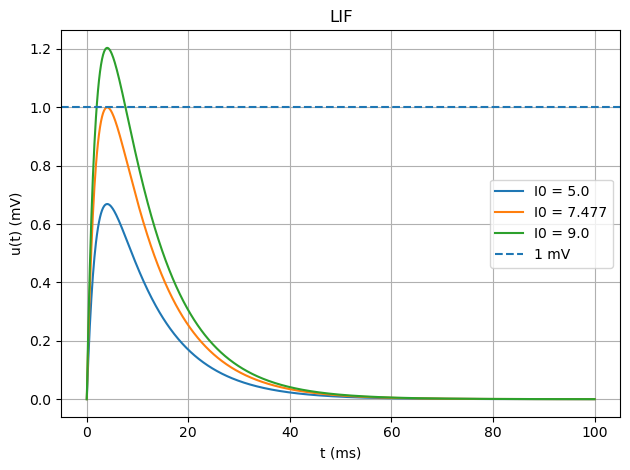

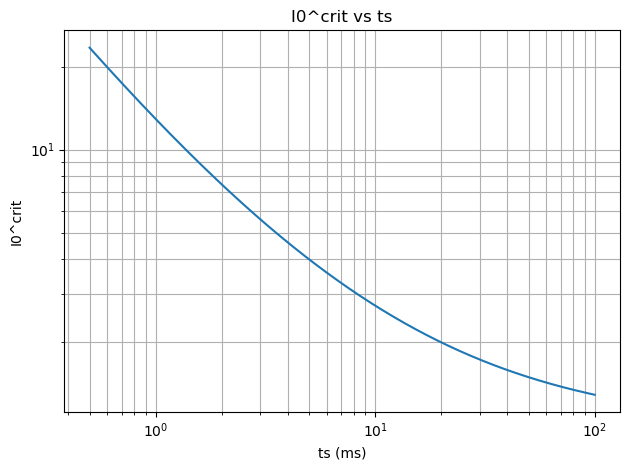

In [11]:
import numpy as np
import matplotlib.pyplot as plt

R = 1.0
tm = 10.0      
ts = 2.0       
uth = 1.0   

t = np.linspace(0, 100, 1000)

I_lst = [5.0, 7.477, 9.0]

for I0 in I_lst:

    u = (R * I0 * ts/ (ts - tm)* (np.exp(-t / ts)- np.exp(-t / tm)))
    plt.plot(t, u, label=f"I0 = {I0}")

plt.axhline(
    y=u_th,
    linestyle="--",
    label="1 mV"
)

plt.xlabel("t (ms)")
plt.ylabel("u(t) (mV)")
plt.title("LIF")

plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

ts_lst = np.logspace(
    np.log10(0.5),
    np.log10(100),
    500
)

Icrit_lst = []

for ts_i in ts_lst:

    r = ts_i / tm

    if np.isclose(r, 1.0):
        Icrit = (uth / R) * np.e
    else:
        Icrit = (uth / R) * r**(1 / (r - 1))

    Icrit_lst.append(Icrit)

plt.figure()

plt.loglog(ts_lst, Icrit_lst)

plt.xlabel("ts (ms)")
plt.ylabel("I0^crit")
plt.title("I0^crit vs ts")

plt.grid(True, which="both")
plt.tight_layout()

plt.show()

Id = 7: 11 spikes, rate = 58.3 Hz
Criterion: at least 3 spikes during the final 100 ms of a 1000 ms simulation.
rheobase = 6.264 


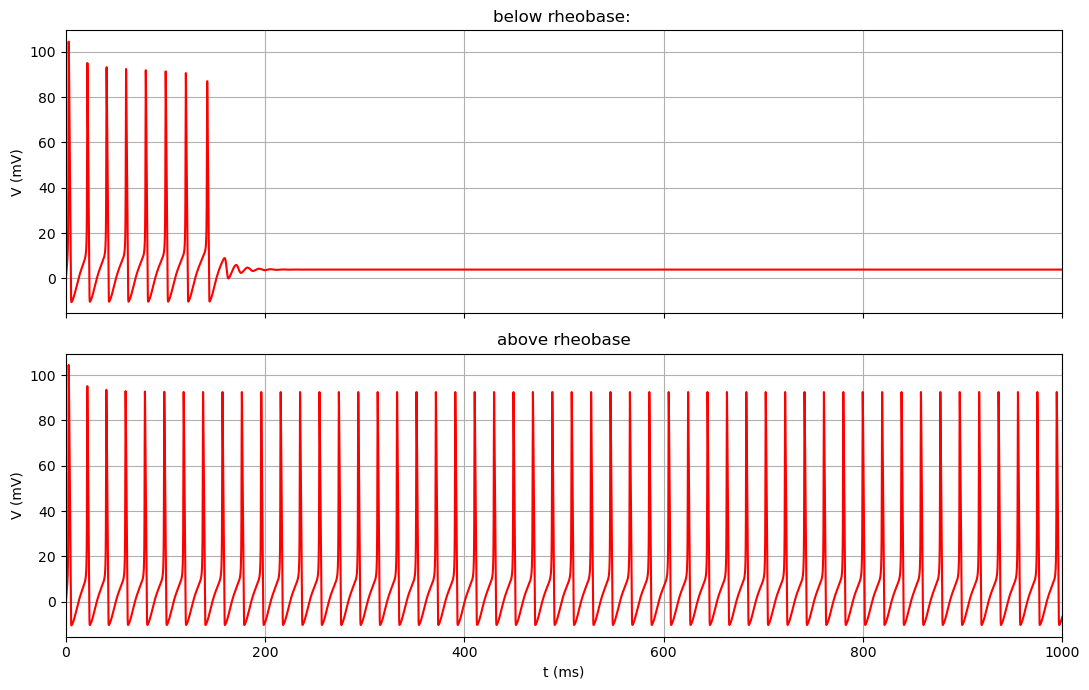

In [22]:
# Part (a)

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp



def _am(V):
    return 1.0 if abs(V - 25) < 1e-6 else 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)


def _bm(V):
    return 4 * np.exp(-V / 18)


def _ah(V):
    return 0.07 * np.exp(-V / 20)


def _bh(V):
    return 1 / (np.exp((30 - V) / 10) + 1)


def _an(V):
    return 0.1 if abs(V - 10) < 1e-6 else 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)


def _bn(V):
    return 0.125 * np.exp(-V / 80)


def hh_sim(Id=7.0, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.4):
    """Integrate the HH model under constant current.

    Parameters
    ----------
    Id : injected current density (uA/cm^2). Defaults to 7, above
         rheobase, so hh_sim() with no arguments gives repetitive
         firing.
    tmax : simulation duration (ms).
    gK, gNa : maximal conductances (mS/cm^2).
    skipfrac : fraction of the trace discarded before counting spikes, so
        that the onset transient is not mistaken for repetitive firing.

    Returns
    -------
    t, V : time vector (ms) and voltage trace (mV).
    spk : spike times, upward crossings of 40 mV.
    rate : mean firing rate in Hz over the counted window, 0 if fewer
        than two spikes.
    """
    C, gL, ENa, EK, EL = 1.0, 0.3, 115.0, -12.0, 10.6

    def rhs(_, y):
        V, m, h, n = y
        INa = gNa * m**3 * h * (V - ENa)
        IK = gK * n**4 * (V - EK)
        IL = gL * (V - EL)
        return [
            (Id - INa - IK - IL) / C,
            _am(V) * (1 - m) - _bm(V) * m,
            _ah(V) * (1 - h) - _bh(V) * h,
            _an(V) * (1 - n) - _bn(V) * n,
        ]

    V0 = 0.0  # steady state gating at rest
    y0 = [
        V0,
        _am(V0) / (_am(V0) + _bm(V0)),
        _ah(V0) / (_ah(V0) + _bh(V0)),
        _an(V0) / (_an(V0) + _bn(V0)),
    ]

    t = np.arange(0, tmax + 1e-9, 0.01)
    sol = solve_ivp(rhs, [0, tmax], y0, method="BDF", t_eval=t,
                    rtol=1e-8, atol=1e-10, max_step=0.05)
    V = sol.y[0]

    i0 = max(1, int(round(skipfrac * len(t))))
    up = np.flatnonzero((V[i0:-1] < 40) & (V[i0 + 1:] >= 40)) + i0
    spk = t[up]

    rate = 1000 * (len(spk) - 1) / (spk[-1] - spk[0]) if len(spk) >= 2 else 0.0
    return t, V, spk, rate


if __name__ == "__main__":
    t, V, spk, rate = hh_sim()
    print(f"Id = 7: {len(spk)} spikes, rate = {rate:.1f} Hz")



def CheckRepetitive(Id):
    """
    Simulate for 1000 ms and examine the final 100 ms.

    At least 3 spikes must occur during the final 100 ms
    for the firing to be classified as repetitive.
    """

    t, V, spk, rate = hh_sim(
        Id=Id,
        tmax=1000.0,
        skipfrac=0.9
    )

    return len(spk) >= 3


def FindRheobase(lowerB=5.0, upperB=7.0, tolerance=1e-4):
    if CheckRepetitive(lowerB):
        raise ValueError("error")
    if not CheckRepetitive(upperB):
        raise ValueError("error")
    while upperB - lowerB > tolerance:

        I_mid = (lowerB + upperB) / 2

        if CheckRepetitive(I_mid):
            upperB = I_mid
        else:
            lowerB = I_mid

    return upperB




if __name__ == "__main__":

    rheobase = FindRheobase()
    print("Criterion: at least 3 spikes during the final 100 ms of a 1000 ms simulation.")

    print(f"rheobase = {rheobase:.3f} ")
    
    Id_below = rheobase - 0.01
    Id_above = rheobase + 0.01

    t_below, V_below, spk_below, rate_below = hh_sim(
        Id=Id_below,
        tmax=1000.0,
        skipfrac=0.9
    )
    t_above, V_above, spk_above, rate_above = hh_sim(
        Id=Id_above,
        tmax=1000.0,
        skipfrac=0.9
    )

    V_min = min(
        V_below.min(),
        V_above.min()
    ) - 5

    V_max = max(
        V_below.max(),
        V_above.max()
    ) + 5

    #two plots
    fig, ax = plt.subplots(
        2,
        1,
        figsize=(11, 7),
        sharex=True
    )

    # below rheobase
    ax[0].plot(
        t_below,
        V_below,
        color="red"
    )

    ax[0].set_title(f"below rheobase: ")

    ax[0].set_ylabel("V (mV)")
    ax[0].set_xlim(0, 1000)
    ax[0].set_ylim(V_min, V_max)
    ax[0].grid()

    # above rheobase
    ax[1].plot(
        t_above,
        V_above,
        color="red"
    )

    ax[1].set_title(f"above rheobase")

    ax[1].set_xlabel("t (ms)")
    ax[1].set_ylabel("V (mV)")
    ax[1].set_xlim(0, 1000)
    ax[1].set_ylim(V_min, V_max)
    ax[1].grid()

    plt.tight_layout()
    plt.show()

onset firing rate: 52.604 hz


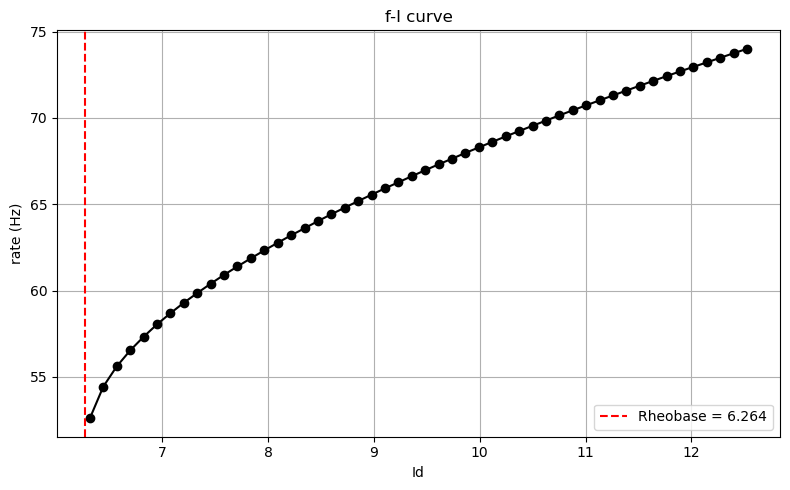

In [26]:
#partB
Id_lst = np.linspace(
    rheobase + 0.05,
    2 * rheobase,
    50
)

rates = []

for Id in Id_lst:

    t, V, spk, rate = hh_sim(
        Id=Id,
        tmax=1000.0,
        skipfrac=0.9
    )

    rates.append(rate)

rates = np.array(rates)

onset_rate = rates[0]

print(f"onset firing rate: {onset_rate:.3f} hz")


plt.figure(figsize=(8, 5))

plt.plot(
    Id_lst,
    rates,
    "o-",
    color="black"
)


plt.axvline(
    rheobase,
    color="red",
    linestyle="--",
    label=f"Rheobase = {rheobase:.3f}"
)

plt.xlabel(
    r"Id"
)

plt.ylabel("rate (Hz)")

plt.title(
    "f-I curve"
)

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

gK (mS/cm^2)    Rheobase (uA/cm^2)
gK36 6.264 mS/cm^2 
gk30 2.777 mS/cm^2 


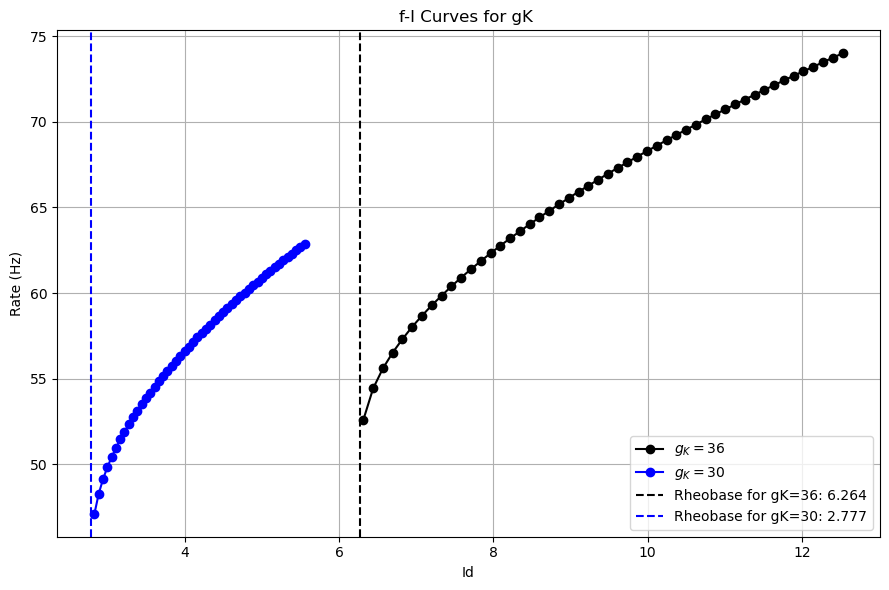

In [32]:
# Part (c)

def CheckRepetitive_gK(Id, gK):
    t, V, spk, rate = hh_sim(
        Id=Id,
        tmax=1000.0,
        gK=gK,
        skipfrac=0.9
    )

    return len(spk) >= 3

def FindRheobase_gK(
    gK,
    lowerB,
    upperB,
    tolerance=1e-4
):

    while upperB - lowerB > tolerance:

        I_mid = (lowerB + upperB) / 2

        if CheckRepetitive_gK(I_mid, gK):
            upperB = I_mid
        else:
            lowerB = I_mid

    return upperB

rheobase36 = FindRheobase_gK(
    gK=36.0,
    lowerB=5.0,
    upperB=7.0
)

rheobase30 = FindRheobase_gK(
    gK=30.0,
    lowerB=0.0,
    upperB=7.0
)


print("gK (mS/cm^2)    Rheobase (uA/cm^2)")
print(f"gK36 {rheobase36:.3f} mS/cm^2 ")
print(f"gk30 {rheobase30:.3f} mS/cm^2 ")


Id_lst36 = np.linspace(
    rheobase36 + 0.05,
    2 * rheobase36,
    50
)


Id_lst30 = np.linspace(
    rheobase30 + 0.05,
    2 * rheobase30,
    50
)


rates36 = []

for Id in Id_lst36:

    t, V, spk, rate = hh_sim(
        Id=Id,
        tmax=1000.0,
        gK=36.0,
        skipfrac=0.9
    )

    rates36.append(rate)

rates36 = np.array(rates36)


rates30 = []

for Id in Id_lst30:

    t, V, spk, rate = hh_sim(
        Id=Id,
        tmax=1000.0,
        gK=30.0,
        skipfrac=0.9
    )

    rates30.append(rate)

rates30 = np.array(rates30)


plt.figure(figsize=(9, 6))

plt.plot(
    Id_lst36,
    rates36,
    "o-",
    color="black",
    label=r"$g_K=36$"
)

plt.plot(
    Id_lst30,
    rates30,
    "o-",
    color="blue",
    label=r"$g_K=30$"
)


plt.axvline(
    rheobase36,
    color="black",
    linestyle="--",
    label=f"Rheobase for gK=36: {rheobase36:.3f}"
)


# Mark rheobase for gK = 30
plt.axvline(
    rheobase30,
    color="blue",
    linestyle="--",
    label=f"Rheobase for gK=30: {rheobase30:.3f}"
)


plt.xlabel("Id")
plt.ylabel("Rate (Hz)")
plt.title("f-I Curves for gK ")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()